# Preprocessing Spatial Transcriptomics Data: Visium and G4X

This notebook walks through **basic preprocessing** for the two most common 10x Genomics spatial platforms:

- **Visium** — spot-based (55 µm spots, ~1-10 cells/spot), whole-transcriptome, from a Space Ranger count matrix + H&E image
- **G4X** — single-cell resolution in situ imaging, targeted gene panel (~300-500 genes), LauLab Sample

Both sections follow the same logical arc: **load → QC metrics → filter → normalize → dimensionality reduction → clustering → spatial visualization**, but the specifics differ meaningfully between a sequencing-based assay (Visium) and an imaging-based assay (Xenium) — e.g. Xenium needs control-probe filtering and cell-area/segmentation QC that Visium doesn't.

> **Datasets used** (both are public 10x Genomics datasets, CC BY 4.0 licensed):
> - Visium: *Human Breast Cancer, Block A Section 1* — fetched directly via `scanpy`'s built-in Space Ranger example downloader, no manual download needed.
> - Xenium: *Human Colon* (Xenium Human Colon Gene Expression Panel, healthy + adenocarcinoma FFPE sections) — from the 10x [Datasets portal](https://www.10xgenomics.com/datasets). This one you download manually (see Part 2), since Xenium bundles are large and the exact URL/version can change over time — copy the current "Xenium Output Bundle" link from the dataset page.

## Environment setup

Run once. `squidpy` pulls in `scanpy`/`anndata`; `leidenalg` is needed for Leiden clustering.


In [4]:
# !pip install scanpy squidpy leidenalg igraph --quiet
# (uncomment above if these aren't already installed in your environment)

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geosketch

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor="white")
# print(f"scanpy=={sc.__version__}, squidpy=={sq.__version__}")


/home/simran/miniconda3/envs/scvi-env/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


---
# Part 1 — Visium

## 1.1 Load data

`scanpy` can fetch official 10x Space Ranger demo datasets directly (counts + spatial coordinates + H&E image) without you having to manually download/unzip anything.

In [3]:
adata_v = sc.datasets.visium_sge(sample_id="V1_Breast_Cancer_Block_A_Section_1")
adata_v.var_names_make_unique()

# If you're working from your own Space Ranger output directory instead, use:
# adata_v = sq.read.visium("/path/to/spaceranger/outs/", counts_file="filtered_feature_bc_matrix.h5")
# adata_v.var_names_make_unique()

adata_v


/tmp/ipykernel_10882/1399532577.py:1: FutureWarning: Use `squidpy.datasets.visium` instead.
  adata_v = sc.datasets.visium_sge(sample_id="V1_Breast_Cancer_Block_A_Section_1")
/home/simran/miniconda3/envs/stlearn/lib/python3.12/site-packages/scanpy/datasets/_datasets.py:555: FutureWarning: Use `squidpy.read.visium` instead.
  return read_visium(sample_dir, source_image_path=source_image_path)
/home/simran/miniconda3/envs/stlearn/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/simran/miniconda3/envs/stlearn/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

## 1.2 QC metrics

For Visium, the standard QC axes are:
- **total counts per spot** and **genes per spot** — low values usually mean poor tissue permeabilization or an empty/background spot
- **% mitochondrial counts** — high values indicate stressed/dying cells (or spots dominated by damaged tissue)
- Optionally **% hemoglobin genes** for blood-contaminated tissue (relevant in some CRC sections with hemorrhagic regions)

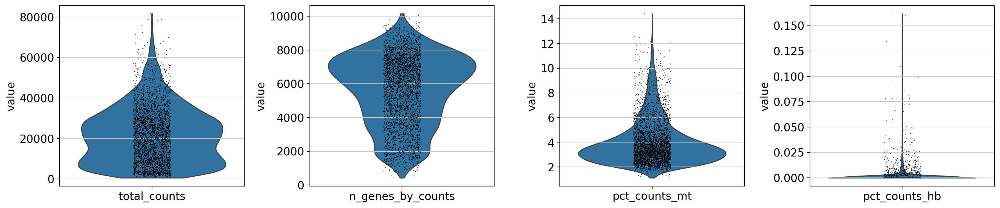

/tmp/ipykernel_10882/2469496937.py:18: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_v, color=["total_counts", "n_genes_by_counts", "pct_counts_mt"], size=1.4)


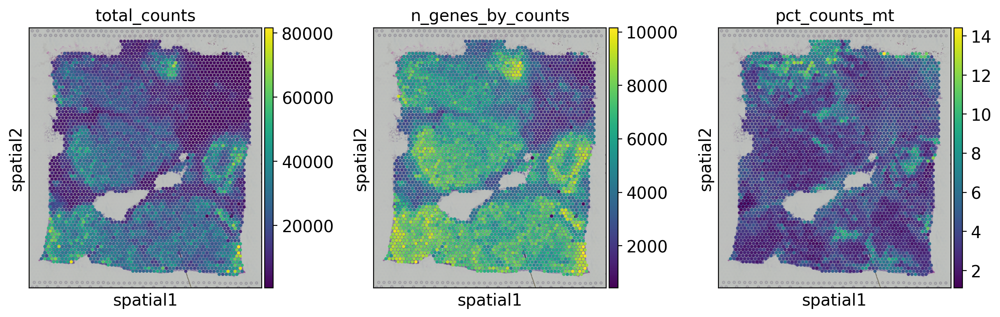

In [4]:
adata_v.var["mt"] = adata_v.var_names.str.startswith("MT-")
adata_v.var["hb"] = adata_v.var_names.str.contains(r"^HB[AB]")

sc.pp.calculate_qc_metrics(
    adata_v, qc_vars=["mt", "hb"], percent_top=None, log1p=False, inplace=True
)

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
sc.pl.violin(adata_v, "total_counts", ax=axs[0], show=False)
sc.pl.violin(adata_v, "n_genes_by_counts", ax=axs[1], show=False)
sc.pl.violin(adata_v, "pct_counts_mt", ax=axs[2], show=False)
sc.pl.violin(adata_v, "pct_counts_hb", ax=axs[3], show=False)
plt.tight_layout()
plt.show()

# spatial view of QC metrics is often more informative than the violins alone —
# e.g. a rim of low-count spots often flags a tissue-detection/alignment issue
sc.pl.spatial(adata_v, color=["total_counts", "n_genes_by_counts", "pct_counts_mt"], size=1.4)


## 1.3 Filtering

Typical starting thresholds (tune per-dataset by inspecting the distributions above — there's no universal cutoff):
- keep spots with **≥ 500 counts** and **≥ 200 genes**
- keep genes detected in **≥ 3 spots**
- drop spots with **> 20% mitochondrial counts**

In [5]:
print(f"Before filtering: {adata_v.n_obs} spots, {adata_v.n_vars} genes")

sc.pp.filter_cells(adata_v, min_counts=500)
sc.pp.filter_cells(adata_v, min_genes=200)
sc.pp.filter_genes(adata_v, min_cells=3)
adata_v = adata_v[adata_v.obs["pct_counts_mt"] < 20].copy()

print(f"After filtering:  {adata_v.n_obs} spots, {adata_v.n_vars} genes")


Before filtering: 3798 spots, 36601 genes
After filtering:  3798 spots, 22240 genes


## 1.4 Normalization

Standard library-size normalization + log transform. Keep the raw counts in `adata.layers["counts"]` — you'll want them later for things like differential expression, TMB-style summaries, or re-normalizing with a different method.

In [6]:
adata_v.layers["counts"] = adata_v.X.copy()

sc.pp.normalize_total(adata_v, target_sum=1e4)
sc.pp.log1p(adata_v)

sc.pp.highly_variable_genes(adata_v, flavor="seurat", n_top_genes=2000)


## 1.5 Dimensionality reduction & clustering

PCA → neighbor graph → Leiden clustering → UMAP, the standard scanpy flow. `use_highly_variable=True` restricts PCA to the HVG subset computed above.

/home/simran/miniconda3/envs/stlearn/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/home/simran/miniconda3/envs/stlearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-24 16:38:49.905808: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-24 16:38:50.157670: I tensorflow/core/p

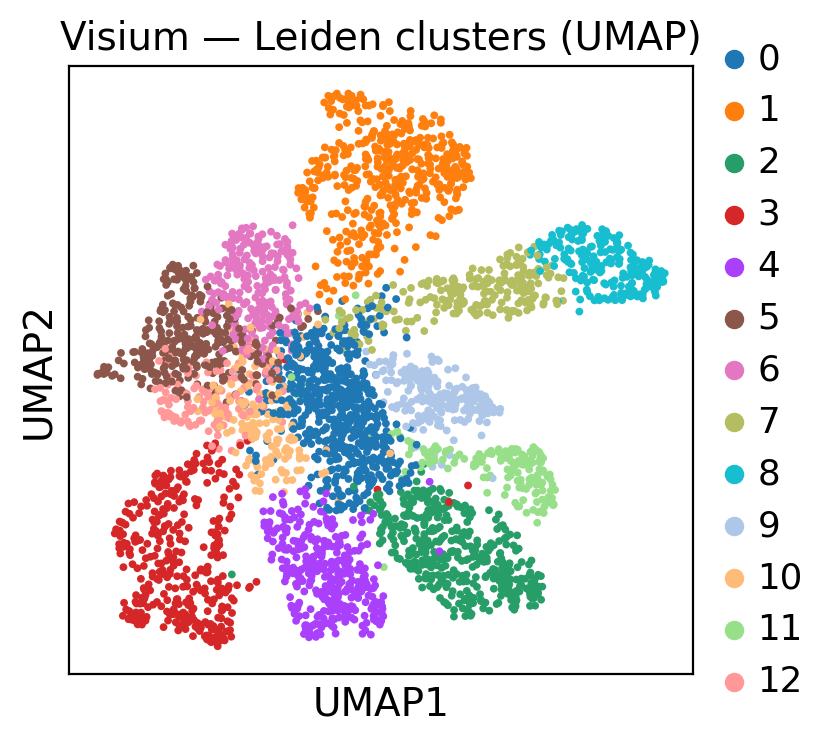

In [7]:
sc.pp.pca(adata_v, n_comps=50, use_highly_variable=True)
sc.pp.neighbors(adata_v)
sc.tl.leiden(adata_v, resolution=1.0, key_added="leiden")
sc.tl.umap(adata_v)

sc.pl.umap(adata_v, color="leiden", title="Visium — Leiden clusters (UMAP)")


In [14]:
adata_v

AnnData object with n_obs × n_vars = 3798 × 22240
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial', 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

## 1.6 Spatial visualization

The payoff of spatial data: view clusters and marker genes back in tissue coordinates. `sc.pl.spatial` overlays `adata.obs`/`adata.var` values directly on the H&E image.

/tmp/ipykernel_10882/3933116281.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_v, color="leiden")


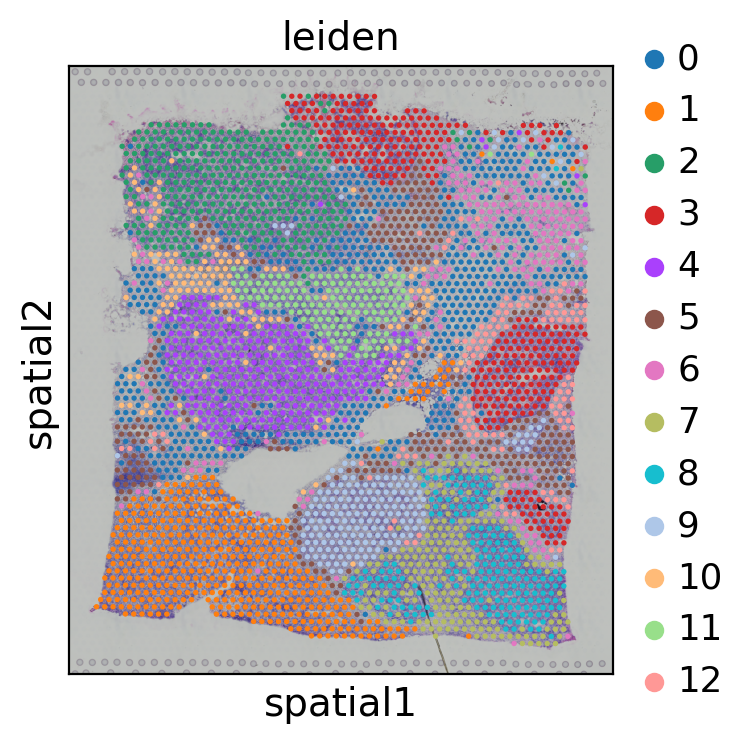

/tmp/ipykernel_10882/3933116281.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_v, color=marker_genes)


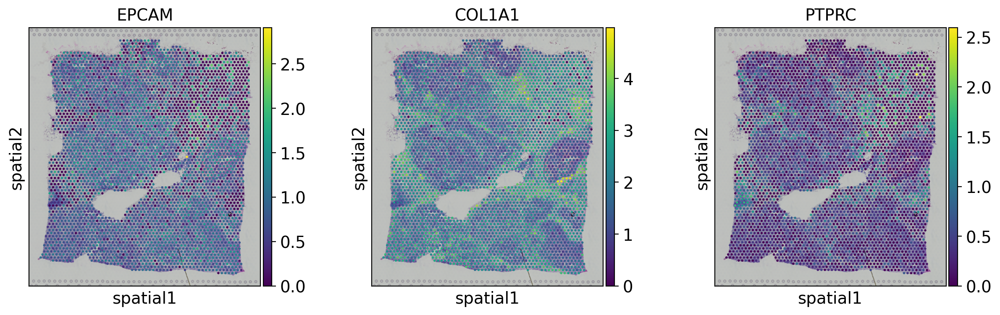

In [15]:
sc.pl.spatial(adata_v, color="leiden")

# example marker genes — swap in genes relevant to your own panel/question
marker_genes = ["EPCAM", "COL1A1", "PTPRC"]
marker_genes = [g for g in marker_genes if g in adata_v.var_names]
if marker_genes:
    sc.pl.spatial(adata_v, color=marker_genes)


## 1.7 Bonus: spatial neighborhood & ligand–receptor enrichment (stlearn) [optional]

`stlearn` adds one thing scanpy doesn't do out of the box: for each spot, it automatically finds the spot's **immediate spatial neighbours** and tests whether ligand–receptor gene pairs are co-expressed within that neighborhood more than expected by chance. That's both the "neighborhood calculation" and the "spatial gene enrichment" in one call — `st.tl.cci.run()`.

This is shown on **Visium** specifically: the neighborhood here is defined per *spot* (a spot + its immediate hex-grid neighbours), which maps naturally onto Visium's array structure. Applying the same approach to G4X/Xenium single-cell data would need "neighborhood" redefined per *cell* (e.g. a fixed physical radius) rather than per spot — outside the scope of this quick example.

Note: `stlearn` has its own plotting functions (`st.pl.*`) for this analysis, separate from `sc.pl`/scanpy — there isn't a scanpy-native equivalent for ligand-receptor hotspot plots, so this one section is the exception to "spatial plots stay in scanpy" used elsewhere in this notebook.

In [ ]:
# pip install stlearn --quiet

import stlearn as st

# stlearn works off a scanpy AnnData -- convert once (uses the uns['spatial'] image info
# already present from sc.datasets.visium_sge)
adata_st = st.convert_scanpy(adata_v.copy())

# per stlearn convention: normalize but do NOT log1p for the LR analysis
adata_st.X = adata_st.layers["counts"].copy()
st.pp.filter_genes(adata_st, min_cells=3)
st.pp.normalize_total(adata_st)

# a small curated ligand-receptor reference panel
lrs = st.tl.cci.load_lrs(["connectomeDB2020_lit"], species="human")
print(f"{len(lrs)} candidate LR pairs loaded")


In [ ]:
# ----- spatial neighborhood calculation + enrichment testing, in one call -----
# For each LR pair: finds each spot's immediate spatial neighbours (distance=None),
# scores ligand-receptor co-expression within that neighborhood, and tests it against
# a background of `n_pairs` randomly matched gene pairs to call significant "hotspots".
# (n_pairs kept low here for a fast example -- use ~10,000 for a real analysis)
st.tl.cci.run(
    adata_st, lrs,
    min_spots=20,
    distance=None,    # None = spot + immediate spatial neighbours
    n_pairs=100,
    n_cpus=None,
    random_state=0,
)

# the neighborhood calculation itself is stored here, independent of the LR scoring:
print("Spot neighbour indices:", adata_st.obsm["spot_neighbours"].shape)

lr_summary = adata_st.uns["lr_summary"]  # LR pairs ranked by number of significant spots
lr_summary.head()


In [ ]:
st.pl.lr_summary(adata_st, n_top=20, figsize=(10, 3))

# spatial plot of the single most significant LR pair's co-expression hotspots
best_lr = lr_summary.index[0]
st.pl.lr_plot(
    adata_st, best_lr,
    inner_size_prop=0.04, middle_size_prop=0.07, outer_size_prop=0.4,
    outer_mode="continuous", pt_scale=60,
    use_label=None, show_image=True, sig_spots=True,
)


---
# Part 2 — Xenium

## 2.1 Get the data

Like G4X, Xenium output bundles are large (imaging, segmentation, per-transcript tables) and aren't fetchable via a one-line loader call, so this is a manual step.

1. Download this dataset from the 10x [Datasets portal](https://www.10xgenomics.com/datasets/xenium-prime-fresh-frozen-mouse-brain) — *Xenium Prime Fresh Frozen Mouse Brain (Coronal)*, run on the Xenium Prime 5K panel.
2. Grab the **"Xenium Output Bundle"** and unzip it locally. At minimum you need:
   - `cell_feature_matrix.h5` — cell x gene counts, CellRanger-style HDF5
   - `cells.csv.gz` — per-cell `cell_id`, `x_centroid`/`y_centroid`, `cell_area`, `nucleus_area`, and other QC columns
3. Any Xenium XOA output folder works with the loader below — this isn't brain/mouse-specific.


In [1]:
path_to_xenium_dir = '/mnt/Data/Xenium_Prime_Mouse_Brain_Coronal_FF_outs/'

## 2.2 Helper functions

Two functions do all the work for this section (and, since they're written generically, get reused as-is for G4X in Part 3):

- **`read_xenium_data`** — loads `cell_feature_matrix.h5` via `sc.read_10x_h5`, reads `cells.csv.gz`, merges it into `adata.obs` by `cell_id`, and builds `adata.obsm["spatial"]` from the `x_centroid`/`y_centroid` columns.
- **`preprocess_broad_clustering`** — the same segmentation QC → count QC/filtering → normalize/log1p/scale → PCA → `geosketch`-subsampled clustering → `sc.tl.ingest` → marker genes pipeline described in Part 3, but parameterized (`area_column`, `use_has_cell`, `leiden_res`, `spot_size`) so it works for both Xenium's and G4X's slightly different per-cell metadata columns.

In [19]:
def read_xenium_data(path_to_xenium_dir):
    adata = sc.read_10x_h5(f"{path_to_xenium_dir}/cell_feature_matrix.h5")
    coords = cell_coords = pd.read_csv(f"{path_to_xenium_dir}/cells.csv.gz")
    cell_coords.set_index('cell_id',inplace=True)
    adata.obs = adata.obs.merge(cell_coords, right_index=True, left_index=True, how= 'left')
    adata.obsm['spatial'] = adata.obs[['x_centroid', 'y_centroid']].values
    return adata

In [43]:
def preprocess_broad_clustering(adata, sample_name, run_name, area_column = 'area', use_has_cell = True, leiden_res = 0.5, spot_size = 100):
    # NOTE: run this AFTER negative-control/control-probe removal, not before --
    # QC metrics, normalize_total, and PCA below all operate on whatever is left
    # in adata.X, so control features need to be gone first or they'll skew
    # library-size normalization and add noise dimensions to the PCA/clustering.
    pre_filter_cells = adata.n_obs
    pre_filter_genes = adata.n_vars
    adata.obs['run_name'] = run_name

    # --- cell-level segmentation QC (G4X-specific, independent of transcript counts) ---
    print(f"NaN cells : {np.count_nonzero(adata.obs[area_column].isna())}")
    print(f"area > 2000 px : {np.count_nonzero(adata.obs[area_column] > 2000)}")
    if use_has_cell:
        print(f"nuclei only cells : {np.count_nonzero(adata.obs['has_cell'] == False)}")

    print("===== Filtering cells now ======")
    # cells with NaN area have zero measurements -- likely stray points, not real segmented cells
    adata = adata[~adata.obs[area_column].isna()].copy()
    # anything above 2000 px is implausibly large to be a single cell (segmentation artifact / fused cells)
    adata = adata[adata.obs[area_column] <= 2000].copy()
    # drop nucleus-only detections that were never matched to a full cell segmentation
    if use_has_cell:
        adata = adata[adata.obs['has_cell'] == True].copy()

    # --- standard count-based QC, computed only after the segmentation-based filtering above ---
    print("===== Calculating qc metrics =====")
    sc.pp.calculate_qc_metrics(adata, percent_top=[20, 50, 100], inplace=True)
    sc.pp.filter_cells(adata, min_genes=5)   # drop cells expressing fewer than 5 genes
    sc.pp.filter_genes(adata, min_cells=3)   # drop genes detected in fewer than 3 cells
    print("===== Cell filtration complete =====")

    print(f"pre filtration cells : {pre_filter_cells}, genes : {pre_filter_genes}")
    print(f"post filtration cells : {adata.n_obs}, genes : {adata.n_vars}")
    print(f"cells filtered : {pre_filter_cells - adata.n_obs}, genes filtered : {pre_filter_genes - adata.n_vars}")

    # --- normalization ---
    print("===== Basic preprocessing and Clustering =====")
    adata.layers['counts'] = adata.X.copy()        # keep raw counts for later (DE, TMB-style summaries, etc.)
    sc.pp.normalize_total(adata)                    # library-size normalize
    sc.pp.log1p(adata)
    adata.layers['log1p_counts'] = adata.X.copy()   # keep log-normalized values before scaling overwrites X
    sc.pp.scale(adata)                              # zero-center/unit-variance scale (in place, in adata.X)
    sc.pp.pca(adata, n_comps=10)
    print("===== Normalization and PCA done ======")

    # --- sketch-based clustering: cluster on a 10% geometric subsample for speed, then
    # propagate labels/embedding back to the full dataset via ingest ---
    N = int(adata.n_obs * 0.1)
    sketch_index = geosketch.gs(adata.obsm['X_pca'], N=N, replace=False)
    adata_sketch = adata[sketch_index].copy()

    sc.pp.neighbors(adata_sketch, use_rep='X_pca', n_neighbors=15, metric='cosine')
    sc.tl.umap(adata_sketch)
    sc.tl.leiden(adata_sketch, resolution=leiden_res, flavor='igraph', n_iterations=2, key_added='leiden')
    sc.pl.umap(adata_sketch, color='leiden')
    sc.pl.spatial(adata_sketch, color='leiden', spot_size=spot_size)

    # map the sketch's clusters + UMAP embedding onto the full (non-subsampled) dataset
    sc.tl.ingest(adata, adata_sketch, obs='leiden', embedding_method='umap')
    sc.pl.umap(adata, color='leiden')
    sc.pl.spatial(adata, color='leiden', spot_size=spot_size)

    # marker genes per cluster, computed on log-normalized (not scaled) values
    sc.tl.rank_genes_groups(adata, groupby='leiden', layer='log1p_counts')
    sc.pl.rank_genes_groups(adata)

    return adata

## 2.3 Load into AnnData

In [44]:
adata = read_xenium_data(path_to_xenium_dir)

## 2.4 Remove control probes

Same as G4X: Xenium panels ship built-in negative controls that aren't real genes and need to come out before any QC/normalization/clustering touches the matrix (see the note inside `preprocess_broad_clustering` above) — `NegControlProbe_*`, `NegControlCodeword_*`, `BLANK_*`, `antisense_*`, `UnassignedCodeword_*`. (The G4X-specific `NCP-`/`NCS-` prefixes are harmless to include here too — they simply won't match anything in a Xenium panel.)

In [ ]:
control_prefixes = ("NegControlProbe_", "NegControlCodeword_", "BLANK_", "antisense_", "UnassignedCodeword_", "NCS-", "NCP-")
is_control = adata.var_names.str.startswith(control_prefixes)

print(f"{is_control.sum()} control features out of {adata.n_vars} total")
print(f"Median control counts/cell: {np.median(np.asarray(adata[:, is_control].X.sum(axis=1))):.2f}")
print(f"Median real-gene counts/cell: {np.median(np.asarray(adata[:, ~is_control].X.sum(axis=1))):.2f}")

adata = adata[:, ~is_control].copy()


## 2.5 QC, filtering, normalization & clustering

Same shared `preprocess_broad_clustering` function used for G4X in Part 3, called here with Xenium-appropriate arguments:
- `area_column='cell_area'` — Xenium's `cells.csv` names this column `cell_area`, not `area`
- `use_has_cell=False` — this Xenium export has no `has_cell` flag (that's a G4X-specific nucleus-vs-cell distinction), so that filter step is skipped
- `spot_size=50` — smaller than G4X's default, tuned for this dataset's cell density in `sc.pl.spatial`

All plotting (UMAP, spatial, marker genes) happens inside the function itself.

NaN cells : 0
area > 2000 px : 0
===== Filtering cells now ======
===== Calculating qc metrics =====
===== Cell filtration complete =====
pre filtration cells : 63173, genes : 5006
post filtration cells : 63153, genes : 5006
cells filtered : 20, genes filtered : 0
===== Basic preprocessing and Clustering =====


/home/simran/miniconda3/envs/scvi-env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


===== Normalization and PCA done ======


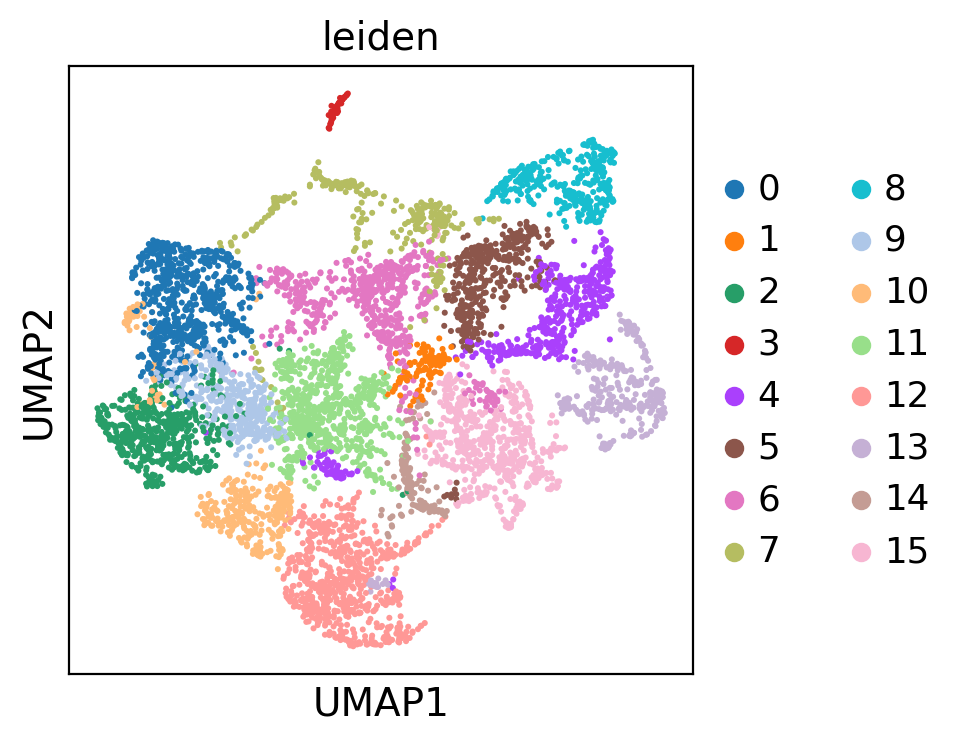

/tmp/ipykernel_16292/1130860711.py:56: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sketch, color='leiden', spot_size=spot_size)


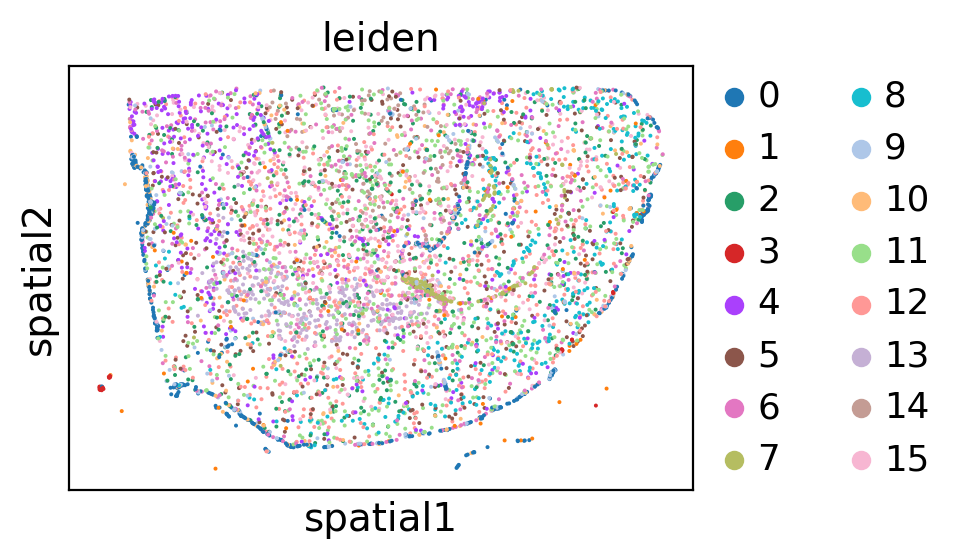

/home/simran/miniconda3/envs/scvi-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


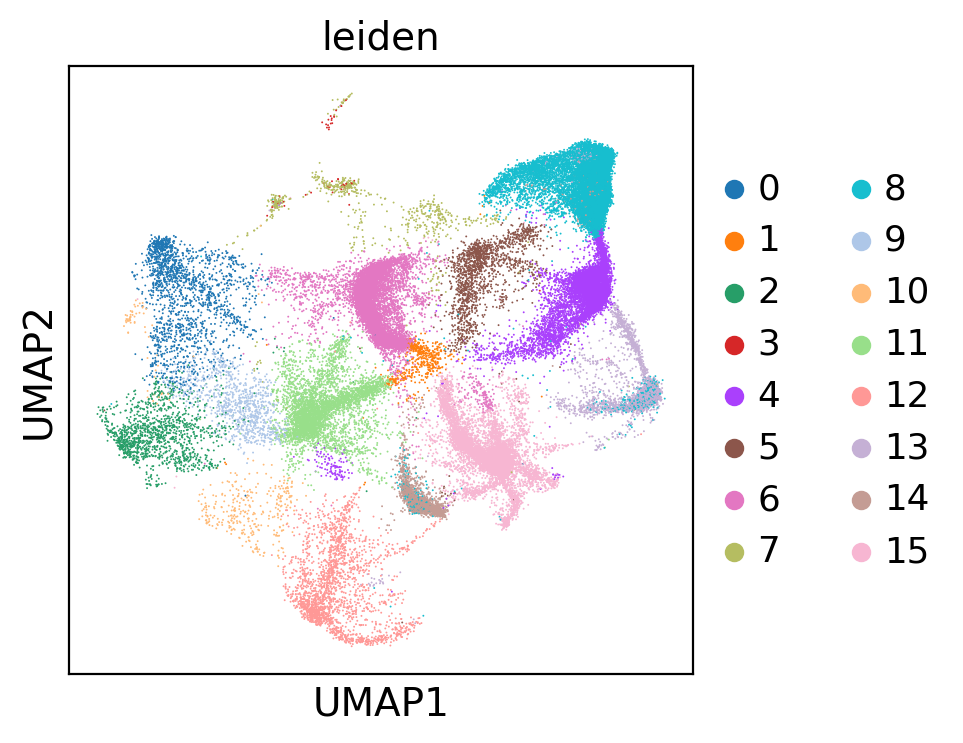

/tmp/ipykernel_16292/1130860711.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='leiden', spot_size=spot_size)


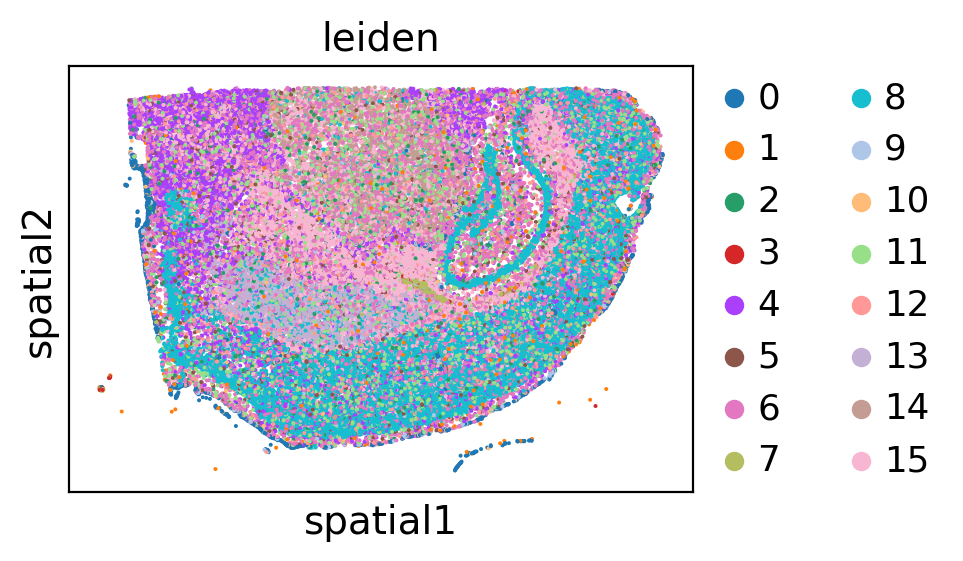

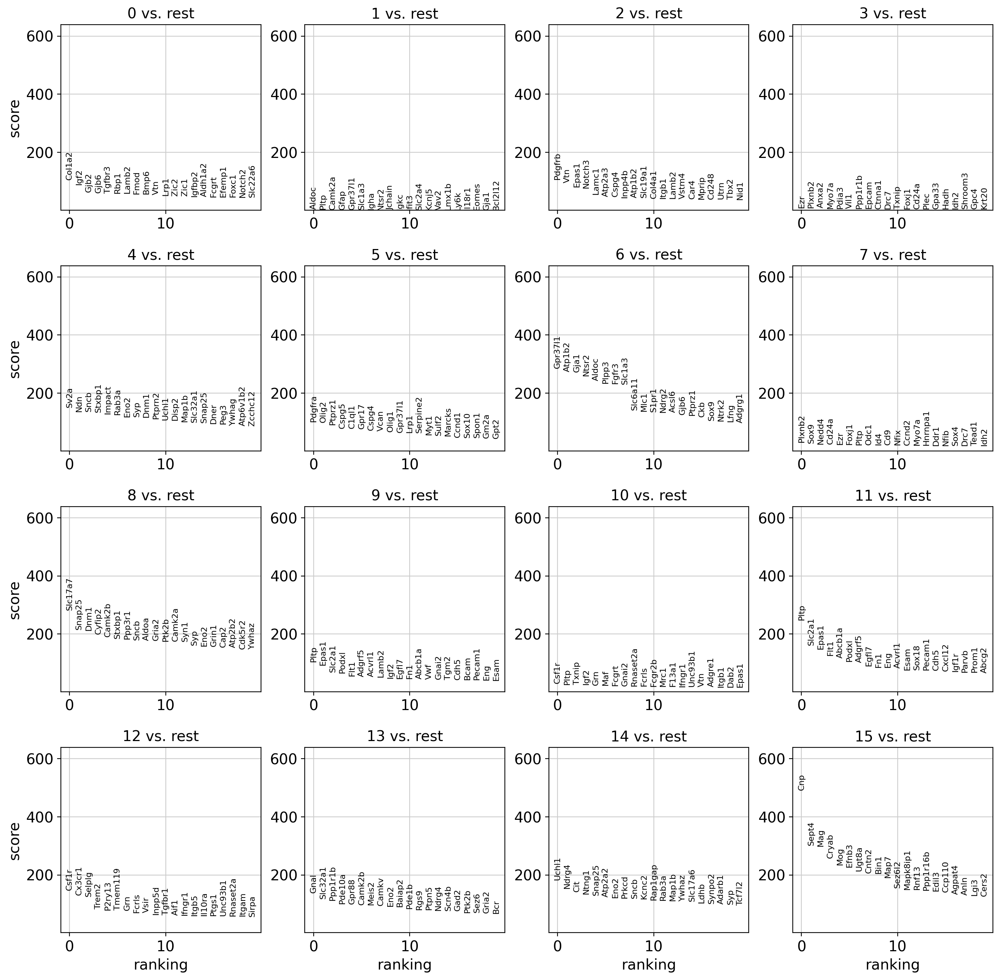

In [45]:
adata = preprocess_broad_clustering(adata, sample_name='mouse_brain_xenium', run_name='run_1', area_column='cell_area', use_has_cell=False, spot_size=50)

---
# Part 3 — G4X

## 3.1 Get the data

G4X (Singular Genomics) output bundles are also large — imaging, segmentation, and per-transcript/per-protein tables — and, like Xenium, aren't fetchable via a one-line loader call, so this is a manual step.

1. G4X data is currently generated either on your own G4X instrument or through Singular's Spatial Services Lab; there isn't yet an open public dataset portal comparable to 10x's, so you'll be working from a run/service delivery rather than a downloadable demo dataset.
2. The delivered output follows a fixed [directory structure](https://docs.singulargenomics.com/g4x_data/output_structure/) with dedicated subfolders for RNA, protein, H&E, segmentation, and single-cell data.
3. For a minimal preprocessing workflow you mainly need the `single_cell_data/` subfolder, which contains:
   - `feature_matrix.h5` — cell x transcript matrix with cell/transcript metadata, loadable straight into scanpy
   - `cell_metadata.csv.gz` — per-cell `label` (cell id), `cell_x`/`cell_y` centroid, `nuclei_area`/`nuclei_expanded_area`, `total_counts`, `n_genes_by_counts`, and (multiomics runs) per-protein `<protein>_intensity_mean` columns
   - `cell_by_transcript.csv.gz` — cell x transcript counts as a flat CSV (same data as the h5, different format)
   - `cell_by_protein.csv.gz` — cell x protein intensity matrix (multiomics runs only)
   - `clustering_umap.csv.gz` / `dgex.csv.gz` — pre-computed Leiden clusters, UMAP coordinates, and differential expression, if you want a starting reference to sanity-check your own reprocessing against

Any G4X `single_cell_data/` output folder works with a loader built against this schema — this isn't tissue-specific.

### How G4X compares to Xenium

Both are imaging-based, single-cell-resolution in situ platforms — the same broad category, distinct from spot-based Visium — so most of what carries over from the Xenium section applies directly:

| | Xenium | G4X |
|---|---|---|
| Unit of measurement | Single segmented cell | Single segmented cell |
| Detection chemistry | Padlock-probe hybridization + optical decoding | Sequencing-by-avidity (in situ SBS), same chemistry family as Singular's G4 NGS instrument |
| Panel | Targeted, ~300–500 genes | Targeted, up to ~500-plex (modular core + add-on panels) |
| Protein readout | Optional add-on (XOA v4.0+) | Native/standard on multiomics runs — protein intensities ship alongside RNA by default |
| Segmentation basis | Nuclear + cell boundary (varies by version) | Nuclear expansion (membrane-based segmentation in development per Singular) |
| Feature matrix format | `.h5`, MEX, or Zarr | `.h5` (scanpy-loadable) or flat CSV (`cell_by_transcript.csv.gz`) |
| Per-cell metadata | `cells.parquet`/`cells.csv.gz`: centroid + `cell_area`/QC columns | `cell_metadata.csv.gz`: centroid (`cell_x`/`cell_y`) + `nuclei_area`/`nuclei_expanded_area` + QC columns |
| Control/background features | Negative control probes/codewords, blanks — must filter from `X` | Not part of the standard single-cell output schema in the same way; check panel documentation for any per-run background controls |
| Pre-computed clustering shipped | No (raw output only) | Yes — `clustering_umap.csv.gz` + `dgex.csv.gz` ship a baseline Leiden clustering/UMAP/DE alongside the raw matrix 

*(`preprocess_broad_clustering` was already defined in the Xenium section above — reused here unchanged.)*

**What this function does:** segmentation QC (`area`, `has_cell`) → count-based QC/filtering → normalize/log1p/scale → PCA → cluster on a `geosketch` subsample → propagate labels/UMAP to all cells via `sc.tl.ingest` → marker genes.

**Why `geosketch`:** G4X samples can have hundreds of thousands–millions of cells, too many to run `neighbors`/`leiden`/`umap` on directly. Random subsampling would risk losing rare populations; `geosketch.gs` instead samples evenly across PCA space, so rare-but-real clusters are more likely to be kept in the 10% sketch used for clustering. `ingest` then maps the full dataset onto that sketch's clusters/embedding.

In [9]:
PATH_TO_G4X_H5AD = '/mnt/storage/Desmoplasia_data/G4X_seg_instaseg/g4x_run_0/A01_WD112575/A01_WD112575.h5ad' # <- point this at your unzipped output folder

adata_x = sc.read_h5ad(PATH_TO_G4X_H5AD)

/home/simran/miniconda3/envs/scvi-env/lib/python3.12/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 3.2 Remove control probes

Xenium and G4X panels include built-in negative controls used to estimate background/false-positive rates — these are **not real genes** and must be dropped before any biological analysis:
- `NegControlProbe_*` — probes with no complementary target, measuring nonspecific binding
- `NegControlCodeword_*` / `BLANK_*` — codewords not assigned to any probe, measuring decoding error
- `antisense_*` — antisense control probes
- `UnassignedCodeword_*` — unused codewords
- `NCP` & `NCS` - g4x negative control prefix

Check counts in these categories first — a real QC signal, not just noise to discard blindly.

In [10]:
control_prefixes = ("NegControlProbe_", "NegControlCodeword_", "BLANK_", "antisense_", "UnassignedCodeword_", 'NCS-', 'NCP-')
is_control = adata_x.var_names.str.startswith(control_prefixes)

print(f"{is_control.sum()} control features out of {adata_x.n_vars} total")
print(f"Median control counts/cell: {np.median(np.asarray(adata_x[:, is_control].X.sum(axis=1))):.2f}")
print(f"Median real-gene counts/cell: {np.median(np.asarray(adata_x[:, ~is_control].X.sum(axis=1))):.2f}")

adata_x = adata_x[:, ~is_control].copy()


39 control features out of 357 total
Median control counts/cell: 0.00
Median real-gene counts/cell: 43.00


/home/simran/miniconda3/envs/scvi-env/lib/python3.12/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 3.3 QC, filtering, normalization & clustering

Xenium and G4X QC differs from Visium in two important ways:
- Each unit is a **single cell**, not a multi-cell spot, so counts/cell are much lower (targeted panel: tens–low hundreds of transcripts, not thousands) — don't reuse Visium thresholds.
- Cell **segmentation quality** matters: `cell_area` (and `nucleus_area`, if present in `cells.csv`) flags mis-segmented cells (fragments, fused cells) that pure count-based QC would miss.

We will use a QC and filtration function written on top.

NaN cells : 363
area > 2000 px : 1499
nuclei only cells : 192
===== Filtering cells now ======


/home/simran/miniconda3/envs/scvi-env/lib/python3.12/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/simran/miniconda3/envs/scvi-env/lib/python3.12/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


===== Calculating qc metrics =====
===== Cell filtration complete =====
pre filtration cells : 474268, genes : 318
post filtration cells : 434985, genes : 318
cells filtered : 39283, genes filtered : 0
===== Basic preprocessing and Clustering =====


/home/simran/miniconda3/envs/scvi-env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


===== Normalization and PCA done ======


2026-07-24 17:41:38.361973: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-24 17:41:38.589777: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


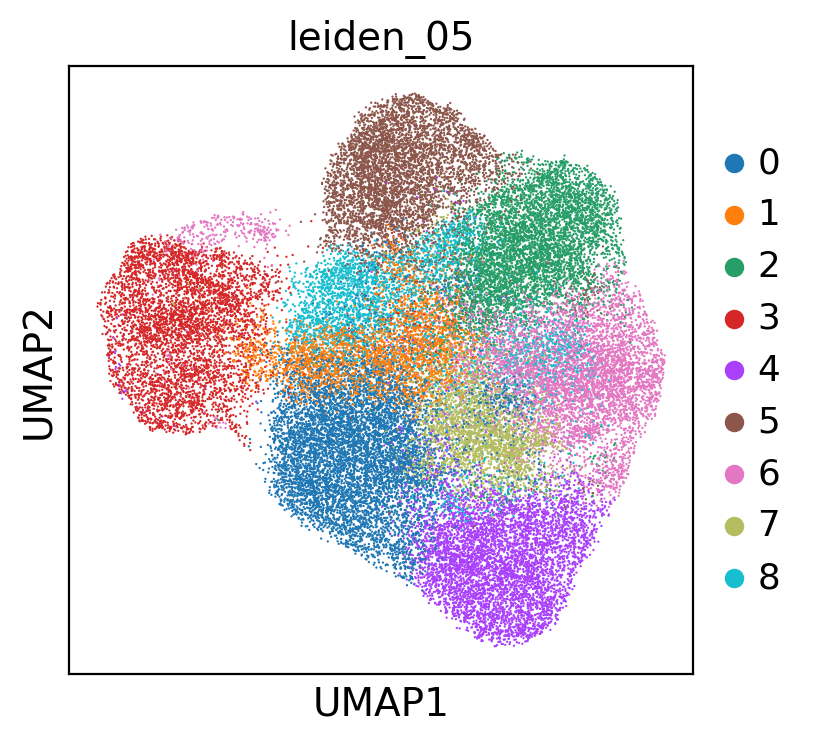

/tmp/ipykernel_15399/3819911491.py:54: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sketch, color='leiden_05', spot_size=100)


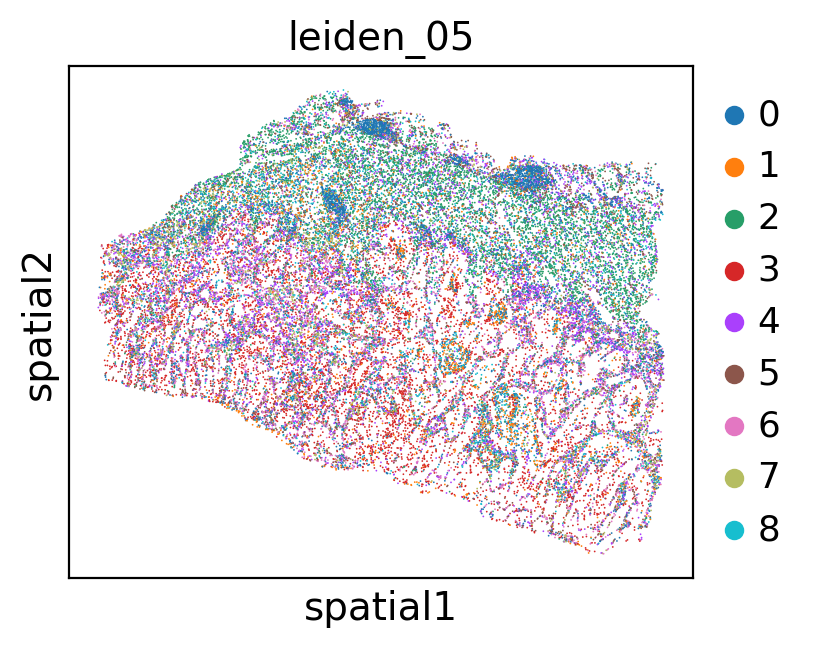

/home/simran/miniconda3/envs/scvi-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


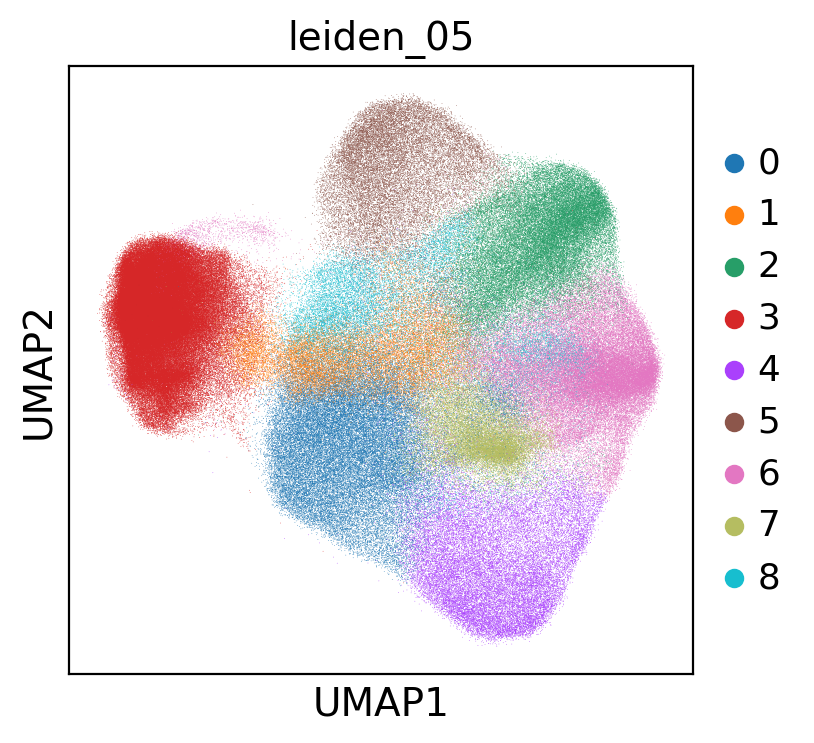

/tmp/ipykernel_15399/3819911491.py:59: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='leiden_05', spot_size=100)


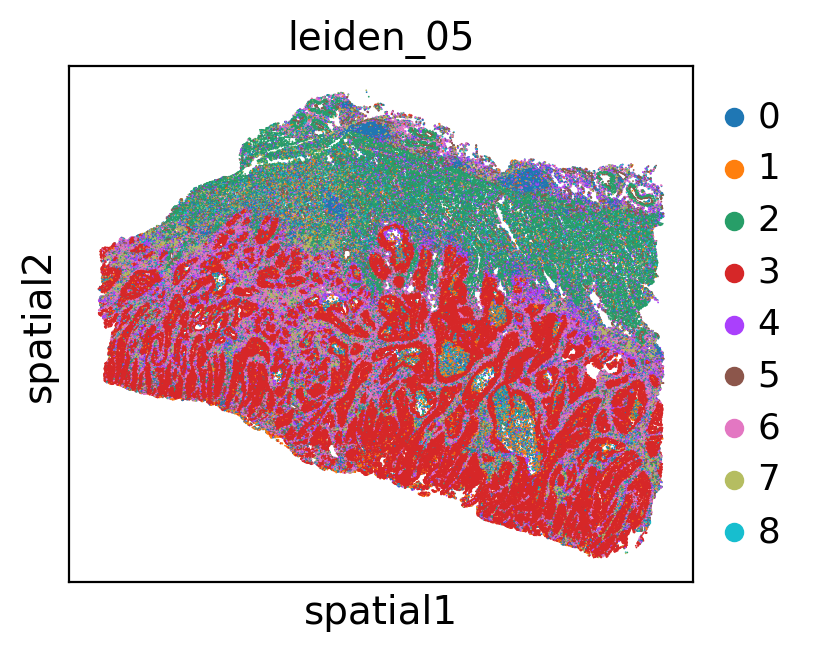

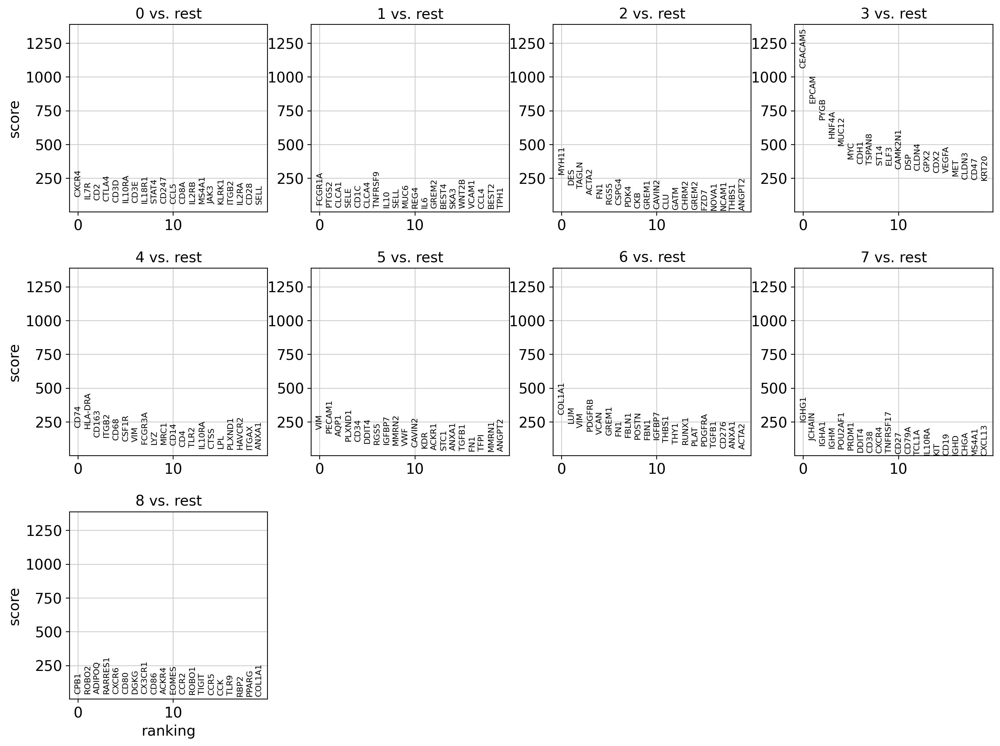

In [14]:
preprocess_broad_clustering(adata_x, 'G4X_sample', 'run_0')

## 3.4 Spatial visualization

G4X's `adata.obsm["spatial"]` holds per-cell (x, y) centroid coordinates at true micron resolution (not spot grid positions), so plots are effectively a spatial map of single cells rather than a hexagonal/grid spot layout, same as Xenium.

In [ ]:
sc.pl.spatial(adata_x, color="leiden", spot_size=100)

# example CRC-relevant markers — replace with genes present in your panel
marker_genes = ["EPCAM", "COL1A1", "PTPRC", "CD3E"]
marker_genes = [g for g in marker_genes if g in adata_x.var_names]
if marker_genes:
    sc.pl.spatial(adata_x, color=marker_genes, spot_size=100)


---
# Summary: Visium vs. Xenium/G4X preprocessing

| Step | Visium | Xenium | G4X |
|---|---|---|---|
| Unit of measurement | Spot (~1-10 cells) | Single segmented cell | Single segmented cell |
| Loading | `sc.datasets.visium_sge()` / `sq.read.visium()` | `sc.read_10x_h5()` + merge `cells.csv.gz` (custom `read_xenium_data`, §2.2) | `sc.read_h5ad()` on `feature_matrix.h5` (manual/service delivery) |
| Panel | Whole transcriptome | Targeted (~300-500 genes) | Targeted (up to ~500-plex) |
| Control features to remove | None (mito/hb tracked as QC, not removed) | Negative control probes/codewords, blanks, antisense — **must remove** | `NCP-`/`NCS-` negative controls — **must remove** |
| Typical count thresholds | Hundreds–thousands of counts/spot | Tens of counts/cell | Tens of counts/cell |
| Extra QC axis | % mitochondrial, % hemoglobin | Cell/nucleus area (segmentation quality) | `area` + `has_cell` (segmentation quality) |
| HVG selection | Standard (e.g. top 2000) | Usually skipped/lenient — panel is pre-curated | Usually skipped/lenient — panel is pre-curated |
| Spatial coordinates | Grid/array spot positions | True micron-resolution cell centroids | True micron-resolution cell centroids |

## Where to go from here

- **Cell type annotation**: score marker gene sets per cluster, or reference-map onto an annotated scRNA-seq atlas (e.g. via `scanpy.tl.ingest`, or `scvi-tools`/scANVI for a trained reference model).
- **Neighborhood/spatial statistics**: the `stlearn` example above (§1.7) covers spot-neighborhood ligand-receptor enrichment on Visium; `squidpy.gr.spatial_neighbors` + `squidpy.gr.nhood_enrichment` (cluster co-localization) and `squidpy.gr.spatial_autocorr` (Moran's I, spatially variable genes) are optional alternatives that work across all three platforms, if you add squidpy back in.
- **Image-derived features** (Visium H&E, or Xenium/G4X morphology image): `squidpy.im.calculate_image_features` for nucleus/texture features per spot or cell.
- **Multi-sample integration**: harmonize several Visium/Xenium/G4X samples (e.g. `scvi`/`scANVI`, Harmony, or scanpy's `bbknn`) before joint clustering, especially important before training a shared reference model across samples.
